# GRUM Paper Reproduction: Experimental Figures

> This notebook is organized by figure. Each section includes the command needed to rerun that figure's experiment when applicable.

## Figure Index

- Figure 1: Informative flowchart in the paper (not an experiment; no reproduction run needed).
- Figure 2: Social-choice asymptotic reproduction (implemented below).
- Figure 3+: Experimental figure sections to be added with run commands.

In [7]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    # If opened from another working directory, try notebook parent traversal
    for parent in Path.cwd().parents:
        if (parent / "configs").exists() and (parent / "scripts").exists():
            ROOT = parent
            break

RESULTS_REPRO_DIR = ROOT / "results/repro"
print(f"Root: {ROOT}")
print(f"Results directory: {RESULTS_REPRO_DIR}")

Root: /home/lotanamit/grums4llms
Results directory: /home/lotanamit/grums4llms/results/repro


## Figure 2: Social-Choice Asymptotic Reproduction

The paper's Figure 2 is a distributional boxplot across agent counts (not a single mean line). This section reproduces that **figure type** by collecting repeated Kendall correlations per agent count and plotting boxplots.

Rerun command template used by the sampling cell (from project root):

```bash
python scripts/run_social_choice_experiment.py \
  --mode asymptotic \
  --dataset dataset2 \
  --agent-counts 50,100,150,200,250,300,350,400,450,500 \
  --repeats 1 \
  --iterations 6 --gibbs-samples 25 --gibbs-burnin 12 \
  --seed <seed> \
  --n-jobs 1 \
  --no-progress \
  --output-json results/repro/figure2_seed_<seed>.json
```

### Read-Only Command Used For Figure 2 Artifacts

```bash
# Single-seed run using the dedicated Figure 2 config
python scripts/run_social_choice_experiment.py \
  --config configs/repro/figure2_social_choice_boxplot.yml
```

```bash
# 20-seed sweep to populate boxplot distributions (run externally, not in notebook)
for s in $(seq 0 19); do
  python scripts/run_social_choice_experiment.py \
    --config configs/repro/figure2_social_choice_boxplot.yml \
    --seed "$s" \
    --output-json "results/repro/figure2_seed_${s}.json"
done
```

```bash
# Optional: also keep the full social-choice paper config run artifact
python scripts/run_social_choice_experiment.py \
  --config configs/repro/social_choice_dataset2_paper.yml \
  --n-jobs 3 \
  --no-progress \
  --output-json results/repro/social_choice_dataset2_paper.json
```

This notebook does not execute these commands. It only reads existing artifacts from results/repro.

In [8]:
# Load existing Figure 2 artifacts only (no experiment reruns in notebook).
fig2_samples_by_count: dict[int, list[float]] = {}

# 1) Prefer pre-aggregated multi-seed samples if they exist.
fig2_samples_path = RESULTS_REPRO_DIR / "figure2_boxplot_samples_dataset2.json"
if fig2_samples_path.exists():
    payload = json.loads(fig2_samples_path.read_text(encoding="utf-8"))
    fig2_samples_by_count = {
        int(k): [float(v) for v in values]
        for k, values in payload.get("samples", {}).items()
    }
    print(f"Loaded pre-aggregated samples: {fig2_samples_path}")
else:
    # 2) Build sample map from any existing per-seed outputs + known repro outputs.
    candidate_files = sorted(RESULTS_REPRO_DIR.glob("figure2_seed_*.json"))
    candidate_files.extend(
        [
            RESULTS_REPRO_DIR / "social_choice_dataset2_paper.json",
            RESULTS_REPRO_DIR / "stageB_asymptotic_dataset2.json",
        ]
    )
    candidate_files = [p for p in candidate_files if p.exists()]

    if not candidate_files:
        raise FileNotFoundError(
            "No Figure 2 artifacts found under results/repro. "
            "Expected at least social_choice_dataset2_paper.json."
        )

    from collections import defaultdict
    by_count = defaultdict(list)

    for fp in candidate_files:
        payload = json.loads(fp.read_text(encoding="utf-8"))
        for point in payload.get("asymptotic", []):
            by_count[int(point["n_agents"])].append(float(point["mean_tau"]))

    fig2_samples_by_count = {k: by_count[k] for k in sorted(by_count.keys())}
    print("Loaded Figure 2 points from files:")
    for fp in candidate_files:
        print(f"- {fp.name}")

FIG2_AGENT_COUNTS = sorted(fig2_samples_by_count.keys())
if not FIG2_AGENT_COUNTS:
    raise ValueError("Figure 2 artifacts were found, but no asymptotic points are available.")

print("\nFigure 2 sample sizes by agent count:")
for n in FIG2_AGENT_COUNTS:
    print(f"n={n}: {len(fig2_samples_by_count[n])} samples")

Loaded Figure 2 points from files:
- social_choice_dataset2_paper.json
- stageB_asymptotic_dataset2.json

Figure 2 sample sizes by agent count:
n=5: 1 samples
n=10: 2 samples
n=20: 2 samples
n=30: 2 samples
n=40: 1 samples
n=50: 1 samples


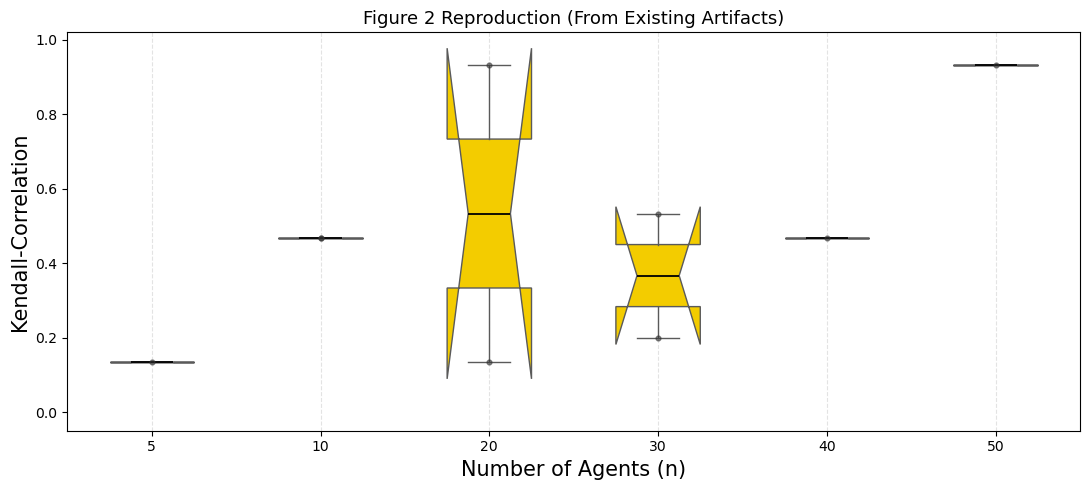

In [9]:
plot_data = [fig2_samples_by_count[n] for n in FIG2_AGENT_COUNTS]

plt.figure(figsize=(11, 5))
plt.boxplot(
    plot_data,
    tick_labels=[str(n) for n in FIG2_AGENT_COUNTS],
    notch=True,
    patch_artist=True,
    showfliers=True,
    whis=1.5,
    medianprops={"color": "black", "linewidth": 1.3},
    boxprops={"facecolor": "#f3cc00", "edgecolor": "#5a5a5a", "linewidth": 1.0},
    whiskerprops={"color": "#5a5a5a", "linewidth": 1.0},
    capprops={"color": "#5a5a5a", "linewidth": 1.0},
    flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#888888", "markeredgecolor": "#666666", "alpha": 0.8},
)

# Overlay raw points so sparse artifacts (1-3 samples) are still visible.
for i, n in enumerate(FIG2_AGENT_COUNTS, start=1):
    vals = np.array(fig2_samples_by_count[n], dtype=float)
    xj = np.full(vals.shape, i, dtype=float)
    plt.scatter(xj, vals, s=12, color="#333333", alpha=0.55, zorder=3)

plt.xlabel("Number of Agents (n)", fontsize=15)
plt.ylabel("Kendall-Correlation", fontsize=15)
plt.ylim(-0.05, 1.02)
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.title("Figure 2 Reproduction (From Existing Artifacts)", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Figure 2 boxplot diagnostics
medians = np.array([np.median(fig2_samples_by_count[n]) for n in FIG2_AGENT_COUNTS], dtype=float)
q1 = np.array([np.percentile(fig2_samples_by_count[n], 25) for n in FIG2_AGENT_COUNTS], dtype=float)
q3 = np.array([np.percentile(fig2_samples_by_count[n], 75) for n in FIG2_AGENT_COUNTS], dtype=float)
iqr = q3 - q1

idx = np.arange(len(FIG2_AGENT_COUNTS), dtype=float)
median_corr = float(np.corrcoef(idx, medians)[0, 1]) if len(medians) > 1 else float("nan")

print("Figure 2 median Kendall by n:")
for n, m, spread in zip(FIG2_AGENT_COUNTS, medians, iqr):
    print(f"n={n:>3}: median={m:.4f}, IQR={spread:.4f}")

print(f"\nTrend corr(index, median): {median_corr:.4f}")
if np.isfinite(median_corr) and median_corr > 0:
    print("Median trend is positive overall.")
else:
    print("Median trend is weak/noisy; artifact coverage may be too small.")

Figure 2 median Kendall by n:
n=  5: median=0.1333, IQR=0.0000
n= 10: median=0.4667, IQR=0.0000
n= 20: median=0.5333, IQR=0.4000
n= 30: median=0.3667, IQR=0.1667
n= 40: median=0.4667, IQR=0.0000
n= 50: median=0.9333, IQR=0.0000

Trend corr(index, median): 0.7838
Median trend is positive overall.


## Other Figure Sections

> Add one section per experimental figure, and include a read-only command block at the top of that section.

> Notebook policy: no rerun options and no `subprocess` calls. Running all cells should only read artifacts under `results/repro` and plot figures.

### Figure 1
- This is an informative flowchart in the paper, not an experiment.
- No rerun script command is required.

### Figure 3+ (Template)
- Add read-only command block first.
- Then add load/plot/diagnostics cells that only read existing JSON artifacts.

```bash
python scripts/run_social_choice_experiment.py --config <figure_specific_config.yml> --output-json <figure_specific_result.json>
```

## Presentation Notes
- Keep each section self-contained so figures can be executed independently.
- Save JSON artifacts per figure under results/repro for traceability.